In [ ]:
# Importations TensorFlow/Keras, SciKit-Learn, PIL, OS, NumPy, OpenCV, Matplotlib
from google.colab import drive
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.metrics import Recall, AUC # Métriques Keras intégrées
from sklearn.model_selection import train_test_split
from PIL import Image
import os
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt
import time # Pour mesurer le temps

# Importations pour métriques post-entraînement
from scipy.spatial.distance import directed_hausdorff # Pour Hausdorff

# Montage Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Fonctions d'augmentation (rotateImage, bruit, change_gamma, color, random_change)

def rotateImage(image, angle):
    image_center = tuple(np.array(image.shape[1::-1])/2)
    rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
    # Correction: Utiliser image.shape[1::-1] pour les dimensions de sortie de warpAffine
    return cv2.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv2.INTER_LINEAR)

def bruit(image):
    # Ajoute du bruit gaussien aléatoire
    # Assurez-vous que l'image est en float pour l'addition avant clip/astype
    image_float = image.astype(np.float32)
    noise = np.random.randn(*image.shape) * random.randint(5, 30)
    noisy_image = np.clip(image_float + noise, 0, 255)
    return noisy_image.astype(np.uint8)

def change_gamma(image, alpha=1.0, beta=0.0):
    # Ajuste la luminosité (beta) et le contraste (alpha)
    # Assurez-vous que l'image est en float pour la multiplication/addition
    image_float = image.astype(np.float32)
    adjusted_image = np.clip(alpha * image_float + beta, 0, 255)
    return adjusted_image.astype(np.uint8)

def color(image, alpha=20):
    # Ajoute une variation de couleur aléatoire
    # Conversion en int32 pour éviter l'overflow/underflow pendant l'addition
    variation = np.random.randint(-alpha, alpha + 1, size=image.shape, dtype=np.int32)
    colored_image = np.clip(image.astype(np.int32) + variation, 0, 255)
    return colored_image.astype(np.uint8)

def random_change(image):
    # Applique aléatoirement certaines transformations (comme votre code)
    img = image.copy() # Travaille sur une copie
    if np.random.randint(2):
        img = change_gamma(img, random.uniform(0.8, 1.2), np.random.randint(-50, 50))
    if np.random.randint(2):
        img = bruit(img)
    if np.random.randint(2):
        img = color(img)
    return img

In [ ]:
# --- Fonction Dice Coefficient  ---
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# --- Modèle U-Net (Votre fonction 'model' originale) ---
def model(nbr):
    entree = layers.Input(shape=(576, 560, 3), dtype='float32')

    # Encodeur
    conv1 = layers.Conv2D(nbr, 3, activation='relu', padding='same')(entree)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Conv2D(nbr, 3, activation='relu', padding='same')(conv1)
    bn1 = layers.BatchNormalization()(conv1)
    pool1 = layers.MaxPool2D()(bn1)

    conv2 = layers.Conv2D(2 * nbr, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Conv2D(2 * nbr, 3, activation='relu', padding='same')(conv2)
    bn2 = layers.BatchNormalization()(conv2)
    pool2 = layers.MaxPool2D()(bn2)

    conv3 = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(conv3)
    bn3 = layers.BatchNormalization()(conv3)
    pool3 = layers.MaxPool2D()(bn3)

    conv4a = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(pool3) # Renommé pour éviter confusion avec décodeur
    conv4a = layers.BatchNormalization()(conv4a)
    conv4a = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(conv4a)
    bn4 = layers.BatchNormalization()(conv4a)
    pool4 = layers.MaxPool2D()(bn4)

    # Bottleneck (8*nbr puis 4*nbr)
    conv_mid = layers.Conv2D(8 * nbr, 3, activation='relu', padding='same')(pool4)
    conv_mid = layers.BatchNormalization()(conv_mid)
    conv_mid = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(conv_mid)
    bn_mid = layers.BatchNormalization()(conv_mid)

    # Décodeur
    up1 = layers.UpSampling2D()(bn_mid)
    concat1 = layers.Concatenate(axis=3)([up1, bn4]) # Skip connection depuis bn4
    # Blocs Conv après concat (8*nbr puis 4*nbr )
    dconv1 = layers.Conv2D(8 * nbr, 3, activation='relu', padding='same')(concat1)
    dconv1 = layers.BatchNormalization()(dconv1)
    dconv1 = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(dconv1)
    dbn1 = layers.BatchNormalization()(dconv1)

    up2 = layers.UpSampling2D()(dbn1)
    concat2 = layers.Concatenate(axis=3)([up2, bn3]) # Skip connection depuis bn3
    # Blocs Conv après concat (4*nbr puis 2*nbr )
    dconv2 = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(concat2)
    dconv2 = layers.BatchNormalization()(dconv2)
    dconv2 = layers.Conv2D(2 * nbr, 3, activation='relu', padding='same')(dconv2)
    dbn2 = layers.BatchNormalization()(dconv2)

    up3 = layers.UpSampling2D()(dbn2)
    concat3 = layers.Concatenate(axis=3)([up3, bn2]) # Skip connection depuis bn2
    # Blocs Conv après concat (2*nbr puis nbr )
    dconv3 = layers.Conv2D(2 * nbr, 3, activation='relu', padding='same')(concat3)
    dconv3 = layers.BatchNormalization()(dconv3)
    dconv3 = layers.Conv2D(nbr, 3, activation='relu', padding='same')(dconv3)
    dbn3 = layers.BatchNormalization()(dconv3)

    up4 = layers.UpSampling2D()(dbn3)
    concat4 = layers.Concatenate(axis=3)([up4, bn1]) # Skip connection depuis bn1
    # Blocs Conv après concat (nbr puis nbr)
    dconv4 = layers.Conv2D(nbr, 3, activation='relu', padding='same')(concat4)
    dconv4 = layers.BatchNormalization()(dconv4)
    dconv4 = layers.Conv2D(nbr, 3, activation='relu', padding='same')(dconv4)
    dbn4 = layers.BatchNormalization()(dconv4)

    # Couche de sortie (comme votre code)
    sortie = layers.Conv2D(1, 1, activation='sigmoid', padding='same')(dbn4)

    return models.Model(inputs=entree, outputs=sortie)


# --- Nouvelles métriques Keras personnalisées (Inchangées) ---

def iou_coef(y_true, y_pred, smooth=1e-6):
    """Coefficient IoU (Intersection over Union) ou Indice de Jaccard."""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

# Sensitivity est géré par tf.keras.metrics.Recall(name='sensitivity')

def specificity(y_true, y_pred):
    """Spécificité (True Negative Rate)."""
    neg_y_true = 1 - y_true
    neg_y_pred = 1 - y_pred
    fp = K.sum(K.cast(K.greater(y_pred, 0.5), 'float32') * K.cast(K.equal(y_true, 0), 'float32'))
    tn = K.sum(K.cast(K.less_equal(y_pred, 0.5), 'float32') * K.cast(K.equal(y_true, 0), 'float32'))
    specificity_val = tn / (tn + fp + K.epsilon())
    return specificity_val

In [ ]:
# Chemins vers les données
dir_images = '/content/drive/MyDrive/DRIVE/training/images/'
dir_mask   = '/content/drive/MyDrive/DRIVE/training/1st_manual/'

# Vérification existence dossiers
if not os.path.isdir(dir_images):
    raise ValueError(f"Le dossier d'images n'existe pas : {dir_images}")
if not os.path.isdir(dir_mask):
    raise ValueError(f"Le dossier de masques n'existe pas : {dir_mask}")

tab_images, tab_masks = [], []
target_height, target_width = 576, 560

print("Chargement et augmentation des données...")

# Boucle de chargement et d'augmentation
for fichier in sorted(os.listdir(dir_images)):
    if fichier.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
        try:
            img_path = os.path.join(dir_images, fichier)
            img_orig = cv2.imread(img_path)
            if img_orig is None: continue
            img_orig = img_orig[:target_height, :target_width]
            if img_orig.shape[0] != target_height or img_orig.shape[1] != target_width:
                img_orig = cv2.resize(img_orig, (target_width, target_height), interpolation=cv2.INTER_AREA)

            num = fichier.split('_')[0]
            file_mask = os.path.join(dir_mask, num + '_manual1.gif')
            if not os.path.exists(file_mask): continue

            img_mask_orig = np.array(Image.open(file_mask))
            if len(img_mask_orig.shape) == 3: img_mask_orig = img_mask_orig[:,:,0]
            img_mask_orig = img_mask_orig[:target_height, :target_width]
            if img_mask_orig.shape[0] != target_height or img_mask_orig.shape[1] != target_width:
                 img_mask_orig = cv2.resize(img_mask_orig, (target_width, target_height), interpolation=cv2.INTER_NEAREST)

            tab_images.append(img_orig)
            tab_masks.append(img_mask_orig)

            for angle in [0, 90, 180, 270]:
                img_r = rotateImage(img_orig, angle)
                mask_rot_mat = cv2.getRotationMatrix2D(tuple(np.array(img_mask_orig.shape[1::-1])/2), angle, 1.0)
                img_mask_r = cv2.warpAffine(img_mask_orig, mask_rot_mat, img_mask_orig.shape[1::-1], flags=cv2.INTER_NEAREST)

                for flip_code in [-1, 0, 1]: # -1: flip horizontal et vertical, 0: vertical, 1: horizontal
                    for flip in [0, 1]: # 0: pas de flip additionnel, 1: flip (selon flip_code)
                        if flip_code == -1 and flip == 0: # Eviter redondance, -1 seul suffit pour flip H&V
                            img_f = cv2.flip(img_r, -1)
                            img_mask_f = cv2.flip(img_mask_r, -1)
                        elif flip_code != -1 and flip == 1:
                            img_f = cv2.flip(img_r, flip_code)
                            img_mask_f = cv2.flip(img_mask_r, flip_code)
                        else: # Soit flip_code est 0 ou 1 et flip est 0 (pas de flip), ou flip_code est -1 et flip est 1 (déjà fait)
                            img_f = img_r.copy()
                            img_mask_f = img_mask_r.copy()


                        img_augmented = random_change(img_f)
                        img_augmented = img_augmented[:target_height, :target_width]
                        img_mask_final = img_mask_f[:target_height, :target_width]

                        if img_augmented.shape[0] == target_height and img_augmented.shape[1] == target_width and \
                           img_mask_final.shape[0] == target_height and img_mask_final.shape[1] == target_width:
                              tab_images.append(img_augmented)
                              tab_masks.append(img_mask_final)

        except Exception as e:
            print(f"Erreur pendant chargement/augmentation pour {fichier}: {e}")

if len(tab_images) > 500:
    print(f"Attention: Plus de 500 images générées ({len(tab_images)}), limitation à 500.")
    indices = random.sample(range(len(tab_images)), 500)
    tab_images = [tab_images[i] for i in indices]
    tab_masks = [tab_masks[i] for i in indices]

print(f"Chargement et augmentation terminés. Nombre total d'échantillons: {len(tab_images)}")
if not tab_images:
     raise SystemExit("Erreur: Aucune image/masque après chargement/augmentation.")

tab_images = np.array(tab_images, dtype=np.float32) / 255.0
tab_masks = np.array(tab_masks, dtype=np.float32) / 255.0
if len(tab_masks.shape) == 3:
    tab_masks = np.expand_dims(tab_masks, axis=-1)
    print(f"Dimension de canal ajoutée aux masques. Nouvelle forme : {tab_masks.shape}")

print(f"Forme finale des images : {tab_images.shape}")
print(f"Forme finale des masques : {tab_masks.shape}")

# Séparer les jeux de données (Création des ensembles d'entraînement, validation et test)
# 80% train, 15% validation, 5% test
train_images, test_val_images, train_masks, test_val_masks = train_test_split(
    tab_images, tab_masks, test_size=0.2, random_state=123 # 80% train, 20% pour test+val
)
val_images, test_images, val_masks, test_masks = train_test_split(
    test_val_images, test_val_masks, test_size=0.25, random_state=123 # 25% de 20% -> 5% test, reste 15% val
)


print(f"\nDonnées divisées :")
print(f"  Entraînement : {train_images.shape[0]} images, {train_masks.shape[0]} masques")
print(f"  Validation : {val_images.shape[0]} images, {val_masks.shape[0]} masques")
print(f"  Test : {test_images.shape[0]} images, {test_masks.shape[0]} masques")

# Libérer la mémoire
del tab_images, tab_masks, test_val_images, test_val_masks

Chargement et augmentation des données...
Attention: Plus de 500 images générées (750), limitation à 500.
Chargement et augmentation terminés. Nombre total d'échantillons: 500
Dimension de canal ajoutée aux masques. Nouvelle forme : (500, 576, 560, 1)
Forme finale des images : (500, 576, 560, 3)
Forme finale des masques : (500, 576, 560, 1)

Données divisées :
  Entraînement : 400 images, 400 masques
  Validation : 75 images, 75 masques
  Test : 25 images, 25 masques


In [ ]:
# Instance utilisée pour l'entraînement dans le code
my_model = model(64) # Crée le modèle U-Net standard avec 64 filtres de base

# Compiler le modèle avec les métriques ajoutées
my_model.compile(optimizer='adam',                 # optimiseur
                 loss='binary_crossentropy',       #  fonction de perte
                 metrics=['accuracy',                # Votre métrique originale
                          dice_coef,
                          iou_coef,                #  IoU / Jaccard
                          Recall(name='sensitivity'), #  Sensitivity (Recall)
                          specificity,             #  Specificity
                          AUC(name='auc_roc')      #  AUC-ROC
                          ])

# Afficher le résumé du modèle qui sera entraîné
print("\nRésumé du modèle U-Net qui sera entraîné :")
my_model.summary()


Résumé du modèle U-Net qui sera entraîné :


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 576, 560,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 576, 560,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 576, 560,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 576, 560,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 576, 560,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 288, 280,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 288, 280,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 288, 280,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 288, 280,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 288, 280,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 144, 140,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 144, 140,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 144, 140,  │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 144, 140,  │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 144, 140,  │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 72, 70,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 72, 70,    │    590,080 │ max_pooling2d_2[

 Total params: 10,194,497 (38.89 MB)

 Trainable params: 10,187,201 (38.86 MB)

 Non-trainable params: 7,296 (28.50 KB)

In [ ]:
# --- AJOUT DES CALLBACKS ---
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Définir le chemin pour sauvegarder le meilleur modèle
checkpoint_filepath_simple = '/content/drive/MyDrive/best_unet_simple.h5'

# Callback EarlyStopping: arrête l'entraînement si val_dice_coef ne s'améliore pas pendant 15 époques
# restore_best_weights=True garantit que le modèle aura les meilleurs poids à la fin
early_stopping = EarlyStopping(monitor='val_dice_coef', patience=15, verbose=1, mode='max', restore_best_weights=True)

# Callback ModelCheckpoint: sauvegarde le modèle uniquement lorsque val_dice_coef s'améliore
model_checkpoint = ModelCheckpoint(filepath=checkpoint_filepath_simple,
                                   save_weights_only=False, # Sauvegarde le modèle complet
                                   monitor='val_dice_coef',
                                   mode='max',
                                   save_best_only=True,
                                   verbose=1) # verbose=1 pour voir quand le modèle est sauvegardé

# --- PARAMETRES D'ENTRAINEMENT AJUSTES ---
EPOCHS = 75
BATCH_SIZE = 4

print(f"\n--- Début de l'entraînement ({EPOCHS} époques, batch size {BATCH_SIZE}) ---")
print(f"Early Stopping surveille '{early_stopping.monitor}' ({early_stopping.mode}) avec patience {early_stopping.patience}.")
print(f"Model Checkpoint sauvegardera le meilleur modèle selon '{model_checkpoint.monitor}' dans '{checkpoint_filepath_simple}'.")

start_training_time = time.time()

# Entraîner le modèle avec les callbacks
history = my_model.fit(train_images, train_masks,
                       epochs=EPOCHS,
                       batch_size=BATCH_SIZE,
                       validation_data=(val_images, val_masks), # UTILISATION DE L'ENSEMBLE DE VALIDATION ICI
                       callbacks=[early_stopping, model_checkpoint],
                       verbose=1) # verbose=1 pour voir la progression

end_training_time = time.time()
training_runtime = end_training_time - start_training_time
print(f"\n--- Entraînement terminé (potentiellement avant {EPOCHS} époques grâce à EarlyStopping) ---")
print(f"Temps d'exécution total de l'entraînement (Runtime) : {training_runtime:.2f} secondes ({training_runtime/60:.2f} minutes)")
print(f"Le meilleur modèle a été sauvegardé à : {checkpoint_filepath_simple}")
# Note: Grâce à restore_best_weights=True dans EarlyStopping, 'my_model' contient maintenant les meilleurs poids.


--- Début de l'entraînement (75 époques, batch size 4) ---
Early Stopping surveille 'val_dice_coef' (max) avec patience 15.
Model Checkpoint sauvegardera le meilleur modèle selon 'val_dice_coef' dans '/content/drive/MyDrive/best_unet_simple.h5'.
Epoch 1/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.7196 - auc_roc: 0.7436 - dice_coef: 0.2014 - iou_coef: 0.1126 - loss: 0.6156 - sensitivity: 0.6398 - specificity: 0.7276
Epoch 1: val_dice_coef improved from -inf to 0.19293, saving model to /content/drive/MyDrive/best_unet_simple.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.7207 - auc_roc: 0.7442 - dice_coef: 0.2019 - iou_coef: 0.1129 - loss: 0.6143 - sensitivity: 0.6394 - specificity: 0.7289 - val_accuracy: 0.2907 - val_auc_roc: 0.6943 - val_dice_coef: 0.1929 - val_iou_coef: 0.1068 - val_loss: 3.7289 - val_sensitivity: 0.9981 - val_specificity: 0.2224
Epoch 2/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 863ms/step - accuracy: 0.9426 - auc_roc: 0.8990 - dice_coef: 0.3887 - iou_coef: 0.2421 - loss: 0.2397 - sensitivity: 0.5261 - specificity: 0.9832
Epoch 2: val_dice_coef did not improve from 0.19293
100/100 ━━━━━━━━━━━━━━━━━━━━ 103s 968ms/step - accuracy: 0.9426 - auc_roc: 0.8991 - dice_coef: 0.3890 - iou_coef: 0.2423 - loss: 0.2394 - sensitivity: 0.5261 - specificity: 0.9832 - val_accuracy: 0.9027 - val_auc_roc: 0.6065 - val_dice_coef: 0.0857 - val_iou_coef: 0.0448 - val_loss: 0.3417 - val_sensitivity: 0.0123 - val_specificity: 0.9887
Epoch 3/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 864ms/step - accuracy: 0.9494 - a

100/100 ━━━━━━━━━━━━━━━━━━━━ 150s 997ms/step - accuracy: 0.9558 - auc_roc: 0.9526 - dice_coef: 0.5977 - iou_coef: 0.4271 - loss: 0.1290 - sensitivity: 0.6293 - specificity: 0.9876 - val_accuracy: 0.9228 - val_auc_roc: 0.8711 - val_dice_coef: 0.3526 - val_iou_coef: 0.2148 - val_loss: 0.2261 - val_sensitivity: 0.2567 - val_specificity: 0.9872
Epoch 6/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.9569 - auc_roc: 0.9568 - dice_coef: 0.6165 - iou_coef: 0.4462 - loss: 0.1239 - sensitivity: 0.6429 - specificity: 0.9878
Epoch 6: val_dice_coef improved from 0.35257 to 0.52324, saving model to /content/drive/MyDrive/best_unet_simple.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 993ms/step - accuracy: 0.9570 - auc_roc: 0.9568 - dice_coef: 0.6166 - iou_coef: 0.4462 - loss: 0.1238 - sensitivity: 0.6430 - specificity: 0.9878 - val_accuracy: 0.9474 - val_auc_roc: 0.9400 - val_dice_coef: 0.5232 - val_iou_coef: 0.3553 - val_loss: 0.1503 - val_sensitivity: 0.4535 - val_specificity: 0.9952
Epoch 7/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 867ms/step - accuracy: 0.9586 - auc_roc: 0.9593 - dice_coef: 0.6255 - iou_coef: 0.4559 - loss: 0.1190 - sensitivity: 0.6568 - specificity: 0.9878
Epoch 7: val_dice_coef improved from 0.52324 to 0.62465, saving model to /content/drive/MyDrive/best_unet_simple.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9586 - auc_roc: 0.9593 - dice_coef: 0.6255 - iou_coef: 0.4559 - loss: 0.1190 - sensitivity: 0.6567 - specificity: 0.9878 - val_accuracy: 0.9560 - val_auc_roc: 0.9506 - val_dice_coef: 0.6247 - val_iou_coef: 0.4551 - val_loss: 0.1277 - val_sensitivity: 0.6260 - val_specificity: 0.9880
Epoch 8/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.9591 - auc_roc: 0.9600 - dice_coef: 0.6381 - iou_coef: 0.4694 - loss: 0.1172 - sensitivity: 0.6670 - specificity: 0.9875
Epoch 8: val_dice_coef did not improve from 0.62465
100/100 ━━━━━━━━━━━━━━━━━━━━ 139s 971ms/step - accuracy: 0.9591 - auc_roc: 0.9600 - dice_coef: 0.6382 - iou_coef: 0.4695 - loss: 0.1172 - sensitivity: 0.6670 - specificity: 0.9875 - val_accuracy: 0.9564 - val_auc_roc: 0.9564 - val_dice_coef: 0.6178 - val_iou_coef: 0.4479 - val_loss: 0.1232 - val_sensitivity: 0.6163 - val_specificity: 0.9894
Epoch 9/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 867ms/step - accuracy: 0.9603 - a

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9857 - auc_roc: 0.9977 - dice_coef: 0.8866 - iou_coef: 0.7965 - loss: 0.0329 - sensitivity: 0.9154 - specificity: 0.9926 - val_accuracy: 0.9685 - val_auc_roc: 0.9465 - val_dice_coef: 0.7939 - val_iou_coef: 0.6595 - val_loss: 0.1323 - val_sensitivity: 0.7829 - val_specificity: 0.9864
Epoch 56/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.9866 - auc_roc: 0.9979 - dice_coef: 0.8922 - iou_coef: 0.8055 - loss: 0.0308 - sensitivity: 0.9208 - specificity: 0.9930
Epoch 56: val_dice_coef did not improve from 0.79394
100/100 ━━━━━━━━━━━━━━━━━━━━ 129s 919ms/step - accuracy: 0.9866 - auc_roc: 0.9979 - dice_coef: 0.8922 - iou_coef: 0.8055 - loss: 0.0308 - sensitivity: 0.9208 - specificity: 0.9930 - val_accuracy: 0.9672 - val_auc_roc: 0.9501 - val_dice_coef: 0.7863 - val_iou_coef: 0.6490 - val_loss: 0.1283 - val_sensitivity: 0.7917 - val_specificity: 0.9841
Epoch 57/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.9870 

100/100 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.9876 - auc_roc: 0.9982 - dice_coef: 0.9004 - iou_coef: 0.8190 - loss: 0.0286 - sensitivity: 0.9264 - specificity: 0.9936 - val_accuracy: 0.9684 - val_auc_roc: 0.9455 - val_dice_coef: 0.7968 - val_iou_coef: 0.6635 - val_loss: 0.1346 - val_sensitivity: 0.7881 - val_specificity: 0.9858
Epoch 60/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.9878 - auc_roc: 0.9983 - dice_coef: 0.9019 - iou_coef: 0.8214 - loss: 0.0282 - sensitivity: 0.9286 - specificity: 0.9935
Epoch 60: val_dice_coef did not improve from 0.79675
100/100 ━━━━━━━━━━━━━━━━━━━━ 92s 920ms/step - accuracy: 0.9878 - auc_roc: 0.9983 - dice_coef: 0.9018 - iou_coef: 0.8213 - loss: 0.0282 - sensitivity: 0.9286 - specificity: 0.9935 - val_accuracy: 0.9682 - val_auc_roc: 0.9430 - val_dice_coef: 0.7942 - val_iou_coef: 0.6600 - val_loss: 0.1374 - val_sensitivity: 0.7771 - val_specificity: 0.9867
Epoch 61/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 859ms/step - accuracy: 0.9880 -

100/100 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9888 - auc_roc: 0.9985 - dice_coef: 0.9099 - iou_coef: 0.8348 - loss: 0.0260 - sensitivity: 0.9356 - specificity: 0.9940 - val_accuracy: 0.9681 - val_auc_roc: 0.9458 - val_dice_coef: 0.7993 - val_iou_coef: 0.6670 - val_loss: 0.1385 - val_sensitivity: 0.8011 - val_specificity: 0.9843
Epoch 64/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.9890 - auc_roc: 0.9986 - dice_coef: 0.9113 - iou_coef: 0.8371 - loss: 0.0255 - sensitivity: 0.9373 - specificity: 0.9941
Epoch 64: val_dice_coef did not improve from 0.79934
100/100 ━━━━━━━━━━━━━━━━━━━━ 97s 970ms/step - accuracy: 0.9890 - auc_roc: 0.9986 - dice_coef: 0.9113 - iou_coef: 0.8371 - loss: 0.0255 - sensitivity: 0.9373 - specificity: 0.9941 - val_accuracy: 0.9683 - val_auc_roc: 0.9453 - val_dice_coef: 0.7977 - val_iou_coef: 0.6648 - val_loss: 0.1371 - val_sensitivity: 0.7913 - val_specificity: 0.9855
Epoch 65/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.9890 -

100/100 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.9899 - auc_roc: 0.9988 - dice_coef: 0.9179 - iou_coef: 0.8484 - loss: 0.0234 - sensitivity: 0.9412 - specificity: 0.9946 - val_accuracy: 0.9692 - val_auc_roc: 0.9393 - val_dice_coef: 0.8037 - val_iou_coef: 0.6732 - val_loss: 0.1463 - val_sensitivity: 0.7798 - val_specificity: 0.9876
Epoch 71/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.9901 - auc_roc: 0.9988 - dice_coef: 0.9198 - iou_coef: 0.8517 - loss: 0.0231 - sensitivity: 0.9437 - specificity: 0.9946
Epoch 71: val_dice_coef did not improve from 0.80368
100/100 ━━━━━━━━━━━━━━━━━━━━ 136s 969ms/step - accuracy: 0.9901 - auc_roc: 0.9988 - dice_coef: 0.9199 - iou_coef: 0.8517 - loss: 0.0231 - sensitivity: 0.9437 - specificity: 0.9946 - val_accuracy: 0.9691 - val_auc_roc: 0.9392 - val_dice_coef: 0.8018 - val_iou_coef: 0.6706 - val_loss: 0.1453 - val_sensitivity: 0.7770 - val_specificity: 0.9876
Epoch 72/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.9903 

100/100 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.9907 - auc_roc: 0.9989 - dice_coef: 0.9238 - iou_coef: 0.8584 - loss: 0.0216 - sensitivity: 0.9464 - specificity: 0.9950 - val_accuracy: 0.9692 - val_auc_roc: 0.9397 - val_dice_coef: 0.8047 - val_iou_coef: 0.6746 - val_loss: 0.1475 - val_sensitivity: 0.7838 - val_specificity: 0.9871
Epoch 75/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.9906 - auc_roc: 0.9989 - dice_coef: 0.9244 - iou_coef: 0.8595 - loss: 0.0220 - sensitivity: 0.9462 - specificity: 0.9949
Epoch 75: val_dice_coef did not improve from 0.80467
100/100 ━━━━━━━━━━━━━━━━━━━━ 137s 970ms/step - accuracy: 0.9906 - auc_roc: 0.9989 - dice_coef: 0.9244 - iou_coef: 0.8595 - loss: 0.0220 - sensitivity: 0.9462 - specificity: 0.9949 - val_accuracy: 0.9687 - val_auc_roc: 0.9405 - val_dice_coef: 0.8018 - val_iou_coef: 0.6706 - val_loss: 0.1463 - val_sensitivity: 0.7854 - val_specificity: 0.9864
Restoring model weights from the end of the best epoch: 74.

--- Entraînem


--- Génération des graphiques de l'historique d'entraînement ---


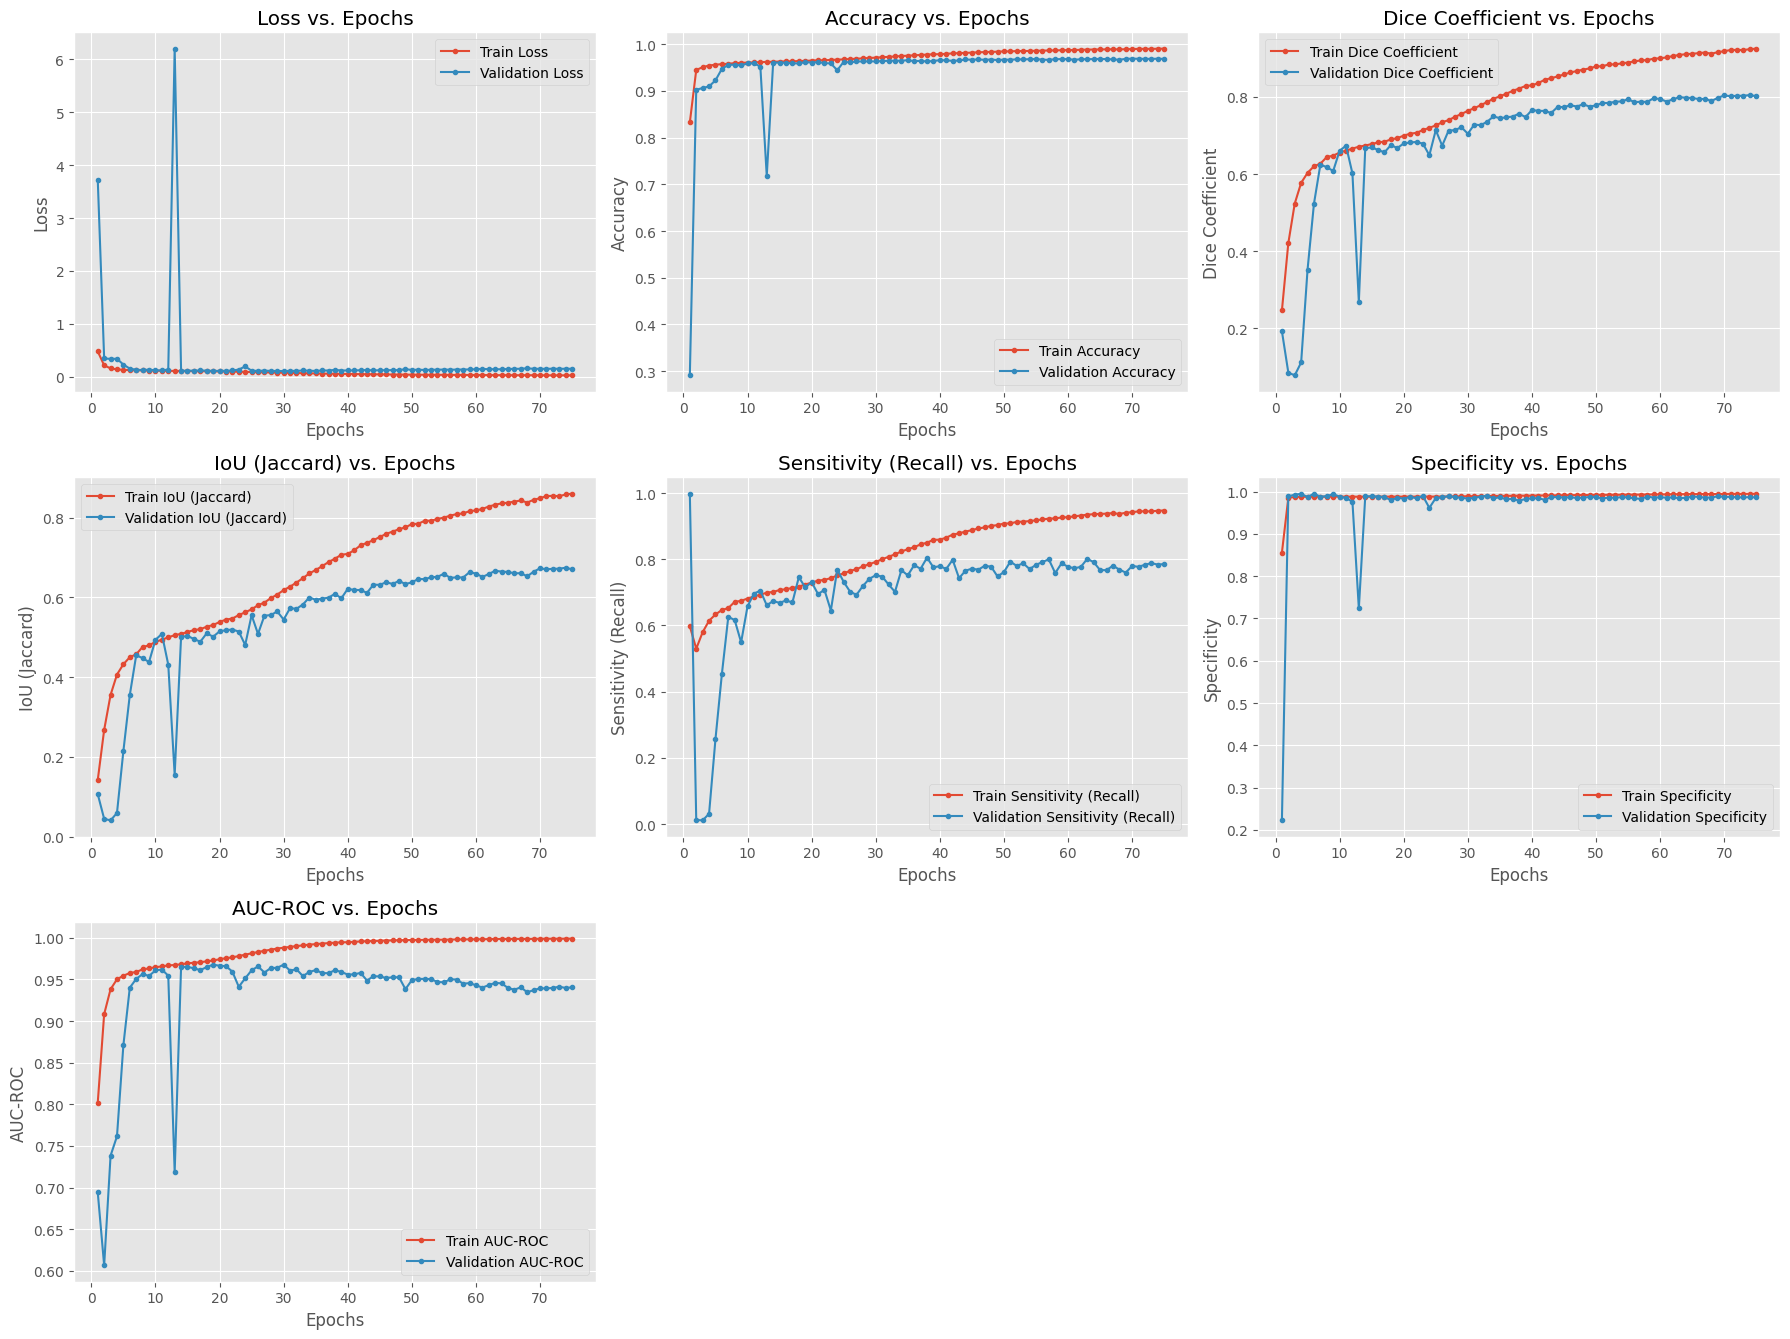


--- Valeurs finales des métriques (dernière époque effectuée / meilleure époque si restore_best_weights=True) ---
--- Loss ---
  Train      : 0.0218
  Validation : 0.1463
--- Accuracy ---
  Train      : 0.9907
  Validation : 0.9687
--- Dice Coefficient ---
  Train      : 0.9249
  Validation : 0.8018
--- IoU (Jaccard) ---
  Train      : 0.8603
  Validation : 0.6706
--- Sensitivity (Recall) ---
  Train      : 0.9472
  Validation : 0.7854
--- Specificity ---
  Train      : 0.9949
  Validation : 0.9864
--- AUC-ROC ---
  Train      : 0.9989
  Validation : 0.9405


In [ ]:
print("\n--- Génération des graphiques de l'historique d'entraînement ---")

history_dict = history.history
&
metrics_to_plot = {
    'loss': 'Loss',
    'accuracy': 'Accuracy',
    'dice_coef': 'Dice Coefficient',
    'iou_coef': 'IoU (Jaccard)',
    'sensitivity': 'Sensitivity (Recall)',
    'specificity': 'Specificity',
    'auc_roc': 'AUC-ROC'
}

num_metrics = len(metrics_to_plot)
num_cols = 3
num_rows = (num_metrics + num_cols - 1) // num_cols

plt.style.use('ggplot')
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 6, num_rows * 4.5))
axes = axes.flatten()

plot_index = 0
for metric_key, metric_name in metrics_to_plot.items():
    if plot_index >= len(axes): break # Sécurité
    ax = axes[plot_index]
    if metric_key in history_dict:
        epochs_range = range(1, len(history_dict[metric_key]) + 1) # Pour l'axe X
        ax.plot(epochs_range, history_dict[metric_key], label=f'Train {metric_name}', marker='.')
        val_metric_key = f'val_{metric_key}'
        if val_metric_key in history_dict:
            ax.plot(epochs_range, history_dict[val_metric_key], label=f'Validation {metric_name}', marker='.')
        else:
            print(f"Note : Pas de données de validation trouvées pour '{val_metric_key}'")
        ax.set_title(f'{metric_name} vs. Epochs')
        ax.set_xlabel('Epochs')
        ax.set_ylabel(metric_name)
        ax.legend()
        plot_index += 1
    else:
        print(f"Attention : Métrique '{metric_key}' non trouvée dans l'historique.")

# Cacher axes non utilisés
for i in range(plot_index, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Affichage valeurs finales
print("\n--- Valeurs finales des métriques (dernière époque effectuée / meilleure époque si restore_best_weights=True) ---")
final_epoch = len(history_dict.get('loss', []))
if final_epoch > 0:
  for metric_key, metric_name in metrics_to_plot.items():
      print(f"--- {metric_name} ---")
      train_val = history_dict.get(metric_key, [np.nan])[-1]
      val_val = history_dict.get(f'val_{metric_key}', [np.nan])[-1]
      print(f"  Train      : {train_val:.4f}")
      print(f"  Validation : {val_val:.4f}")
else:
  print("L'entraînement n'a pas produit d'historique.")

In [ ]:
print("\n--- Évaluation post-entraînement sur l'ensemble de test interne (U-Net Simple) ---")
# 'my_model' a les meilleurs poids grâce à restore_best_weights=True

# 1. Temps d'Inférence sur l'ensemble de test interne
num_test_internal_samples = len(test_images) # Utilise test_images de la Cellule 4
if num_test_internal_samples > 0:
    print(f"Calcul du temps d'inférence sur {num_test_internal_samples} images de test interne...")
    start_inference_time_int = time.time()
    inference_batch_size_int = min(BATCH_SIZE, num_test_internal_samples)
    predictions_prob_test_int = my_model.predict(test_images, batch_size=inference_batch_size_int) # MODIFIÉ ICI : my_model_simple -> my_model
    end_inference_time_int = time.time()

    total_inference_time_int = end_inference_time_int - start_inference_time_int
    avg_inference_time_per_image_int = total_inference_time_int / num_test_internal_samples
    print(f"  Temps d'inférence total (test interne): {total_inference_time_int:.4f} s")
    print(f"  Temps d'inférence moyen par image (test interne): {avg_inference_time_per_image_int:.6f} s")

    # 2. Distance de Hausdorff sur l'ensemble de test interne
    print(f"\nCalcul de la distance de Hausdorff (test interne)...")
    predictions_binary_test_int = (predictions_prob_test_int > 0.5).astype(np.uint8)
    test_masks_binary_int = (test_masks > 0.5).astype(np.uint8) # Utilise test_masks de la Cellule 4

    hausdorff_distances_int = []
    for i in range(num_test_internal_samples):
        gt_mask = test_masks_binary_int[i].squeeze()
        pred_mask = predictions_binary_test_int[i].squeeze()
        coords_gt = np.argwhere(gt_mask > 0)
        coords_pred = np.argwhere(pred_mask > 0)

        if coords_gt.shape[0] > 0 and coords_pred.shape[0] > 0:
            try:
                hd1 = directed_hausdorff(coords_gt, coords_pred)[0]
                hd2 = directed_hausdorff(coords_pred, coords_gt)[0]
                hausdorff_distances_int.append(max(hd1, hd2))
            except Exception as e:
                hausdorff_distances_int.append(np.nan)
        elif coords_gt.shape[0] == 0 and coords_pred.shape[0] == 0:
            hausdorff_distances_int.append(0.0)
        else:
            hausdorff_distances_int.append(np.nan)

    valid_distances_int = [d for d in hausdorff_distances_int if not np.isnan(d)]
    if valid_distances_int:
        avg_hausdorff_int = np.mean(valid_distances_int)
        std_hausdorff_int = np.std(valid_distances_int)
        print(f"  Distance de Hausdorff Moyenne (test interne): {avg_hausdorff_int:.4f}")
        print(f"  Distance de Hausdorff Écart-type (test interne): {std_hausdorff_int:.4f}")
    else:
        print("  Aucune distance de Hausdorff valide (test interne).")
else:
    print("Ensemble de test interne vide.")


--- Évaluation post-entraînement sur l'ensemble de test interne (U-Net Simple) ---
Calcul du temps d'inférence sur 25 images de test interne...
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step
  Temps d'inférence total (test interne): 20.9334 s
  Temps d'inférence moyen par image (test interne): 0.837334 s

Calcul de la distance de Hausdorff (test interne)...
  Distance de Hausdorff Moyenne (test interne): 31.2624
  Distance de Hausdorff Écart-type (test interne): 14.2134


In [ ]:
print("\n--- Prédictions sur le dossier de test externe DRIVE (U-Net Simple) ---")

# Chemins et création dossier pour UNETSIMPLE
dir_drive_test_images = '/content/drive/MyDrive/DRIVE/test/images/'
dir_drive_predictions_simple = '/content/drive/MyDrive/DRIVE_predictions_unet_simple/'
os.makedirs(dir_drive_predictions_simple, exist_ok=True)

if not os.path.isdir(dir_drive_test_images):
    print(f"Warning: Dossier de test externe DRIVE {dir_drive_test_images} non trouvé. Section ignorée.")
else:
    print(f"Chargement des images depuis: {dir_drive_test_images}")
    print(f"Sauvegarde des prédictions U-Net Simple dans: {dir_drive_predictions_simple}")

    fichiers_drive_test = sorted(os.listdir(dir_drive_test_images))
    processed_drive_test_count = 0
    for fichier in fichiers_drive_test:
         if fichier.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
            try:
                img_path = os.path.join(dir_drive_test_images, fichier)
                image_ext = cv2.imread(img_path)
                if image_ext is None:
                    print(f"Warning: Impossible de lire {fichier} (DRIVE test), ignoré.")
                    continue

                # Redimensionner/Recadrer à target_height x target_width (taille d'entrée du modèle)
                image_ext_resized = image_ext[:target_height, :target_width]
                if image_ext_resized.shape[0] != target_height or image_ext_resized.shape[1] != target_width:
                    image_ext_resized = cv2.resize(image_ext, (target_width, target_height), interpolation=cv2.INTER_AREA)

                image_ext_norm = np.array(image_ext_resized, dtype=np.float32) / 255.0
                image_ext_batch = image_ext_norm[np.newaxis, ...]

                # Prédiction avec le meilleur modèle sauvegardé
                # Charger le meilleur modèle si ce n'est pas déjà celui en mémoire
                # Si EarlyStopping a restore_best_weights=True, my_model_simple est déjà le meilleur.
                # Sinon, charger explicitement: best_model_simple = models.load_model(checkpoint_filepath_simple, custom_objects={'dice_coef': dice_coef, ...})
                # Pour simplifier, on assume que my_model_simple a les meilleurs poids.
                prediction_prob_drive = my_model.predict(image_ext_batch)[0]

                # Redimensionner le masque de sortie à 584x565 (taille originale des masques DRIVE test si besoin)
                # ou sauvegarder à la taille de prédiction (576x560)
                # Ici, on sauvegarde à la taille de prédiction pour la cohérence
                output_pred_h, output_pred_w = prediction_prob_drive.shape[:2] # 576, 560

                # Mettre à l'échelle la prédiction (0-1 -> 0-255) et convertir en binaire si besoin
                mask_out_drive = (prediction_prob_drive * 255.0).astype(np.uint8)
                # Si vous voulez un masque binaire (0 ou 255):
                # mask_out_drive = ((prediction_prob_drive > 0.5) * 255).astype(np.uint8)


                # Assurer que le masque a une dimension de canal pour imwrite si nécessaire
                if len(mask_out_drive.shape) == 3 and mask_out_drive.shape[-1] == 1:
                    mask_out_drive_squeezed = mask_out_drive.squeeze()
                else:
                    mask_out_drive_squeezed = mask_out_drive


                base_name = os.path.splitext(fichier)[0]
                # S'assurer que le nom de fichier de sortie est unique et correspond à l'image d'entrée
                # Par exemple, si fichier est '01_test.tif', save_path sera 'pred_01_test.png'
                save_path_drive = os.path.join(dir_drive_predictions_simple, f"pred_simple_{base_name}.png")

                cv2.imwrite(save_path_drive, mask_out_drive_squeezed)
                processed_drive_test_count += 1
            except Exception as e:
                print(f"Erreur lors de la prédiction pour {fichier} (DRIVE test): {e}")
    print(f"{processed_drive_test_count} prédictions (U-Net Simple) sauvegardées dans {dir_drive_predictions_simple}")


--- Prédictions sur le dossier de test externe DRIVE (U-Net Simple) ---
Chargement des images depuis: /content/drive/MyDrive/DRIVE/test/images/
Sauvegarde des prédictions U-Net Simple dans: /content/drive/MyDrive/DRIVE_predictions_unet_simple/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━

In [ ]:
# Enregistrer l'état final du modèle (qui a les meilleurs poids si restore_best_weights=True)
model_save_path_final_simple = '/content/drive/MyDrive/final_unet_simple_ep75_b4.h5' # Nom de fichier mis à jour
my_model.save(model_save_path_final_simple)
print(f"\nModèle final (U-Net Simple) enregistré sous : {model_save_path_final_simple}")
print(f"Le MEILLEUR modèle basé sur '{model_checkpoint.monitor}' est dans : {checkpoint_filepath_simple}")

print("\n--- Fin du script U-Net Simple ---")


Modèle final (U-Net Simple) enregistré sous : /content/drive/MyDrive/final_unet_simple_ep75_b4.h5
Le MEILLEUR modèle basé sur 'val_dice_coef' est dans : /content/drive/MyDrive/best_unet_simple.h5

--- Fin du script U-Net Simple ---
